# RAG Pipeline Evaluation Analysis

Analyses the binary-judge evaluation results produced by `src/process/rag_pipeline.py`.

**What this notebook covers:**
1. Load & validate evaluation CSVs
2. Overall accuracy per strategy
3. Per-decile accuracy — popularity bias
4. Retrieval quality — Recall@K
5. Per-dataset breakdown
6. Score distribution & reasoning inspection
7. Cross-strategy comparison
8. Export summary

In [12]:
from __future__ import annotations

import ast
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Repo root on path ─────────────────────────────────────────────────────────
# In a notebook __file__ is undefined; walk up from cwd (notebook is 2 levels deep)
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / "config.py").exists() and _REPO_ROOT.parent != _REPO_ROOT:
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from config import DATA_DIR

print(f"DATA_DIR: {DATA_DIR}")

DATA_DIR: /Users/cyro/Documents/VSC/PopularityBias/data


## Configuration

Set `COLLECTION_NAME` and `OUTPUT_DIR` to match the `PipelineConfig` used when the pipeline was run.

In [13]:
# ── Match these to your PipelineConfig values ─────────────────────────────────
COLLECTION_NAME = "wiki_full_bil"
OUTPUT_DIR      = "evaluation_results_nq_turbo"
STRATEGIES      = ["approximation", "bm25"]
NUM_DECILES     = 10

RESULTS_DIR = Path(DATA_DIR) / COLLECTION_NAME / OUTPUT_DIR
print(f"Looking for results in: {RESULTS_DIR}")

# Confirm files exist
for s in STRATEGIES:
    p = RESULTS_DIR / f"evaluation_results_{s}.csv"
    status = "found" if p.exists() else "MISSING"
    print(f"  {p.name}: {status}")

Looking for results in: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo
  evaluation_results_approximation.csv: found
  evaluation_results_bm25.csv: found


## 1. Load & Validate Results

In [14]:
def _parse_metadata(val) -> dict:
    """Parse the 'metadata' column, which may be a dict, a JSON string, or a Python repr."""
    if isinstance(val, dict):
        return val
    if isinstance(val, str):
        try:
            import json as _json
            return _json.loads(val)
        except Exception:
            pass
        try:
            return ast.literal_eval(val)
        except Exception:
            pass
    return {}


def _parse_id_list(val) -> list[int]:
    """Coerce a retrieved_doc_ids value to a list of ints.

    The field may arrive as:
      - already a list (e.g. [19367245])
      - a string repr  (e.g. "[19367245]")
    """
    if isinstance(val, list):
        return [int(v) for v in val]
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return [int(v) for v in parsed]
        except Exception:
            pass
    return []


def load_results(strategy: str) -> pd.DataFrame:
    """Load and normalise an evaluation CSV for one strategy."""
    path = RESULTS_DIR / f"evaluation_results_{strategy}.csv"
    df = pd.read_csv(path)

    # Unpack metadata dict into flat columns
    meta = df["metadata"].apply(_parse_metadata)
    df["wikipedia_id"]      = meta.apply(lambda m: m.get("wikipedia_id"))
    df["decile"]            = meta.apply(lambda m: m.get("decile"))
    df["dataset"]           = meta.apply(lambda m: m.get("dataset", "unknown"))
    df["retrieved_doc_ids"] = meta.apply(lambda m: _parse_id_list(m.get("retrieved_doc_ids", [])))

    # Normalise wikipedia_id to int for consistent comparison
    df["wikipedia_id_int"] = pd.to_numeric(df["wikipedia_id"], errors="coerce")

    # Hit: is the target doc anywhere in the retrieved list?
    df["hit"] = df.apply(
        lambda r: int(r["wikipedia_id_int"]) in r["retrieved_doc_ids"]
        if pd.notna(r["wikipedia_id_int"]) and r["retrieved_doc_ids"]
        else False,
        axis=1,
    )

    # Normalise evaluation_score to bool
    df["correct"] = df["evaluation_score"].map(
        lambda v: bool(v) if not isinstance(v, str)
        else v.strip().lower() in {"true", "1", "yes"}
    )

    df["strategy"] = strategy
    return df


raw: dict[str, pd.DataFrame] = {}
for s in STRATEGIES:
    try:
        raw[s] = load_results(s)
        print(f"  {s}: {len(raw[s]):,} rows")
        has_ids = raw[s]["retrieved_doc_ids"].apply(bool).sum()
        print(f"    retrieved_doc_ids present in {has_ids:,} / {len(raw[s]):,} rows")
    except FileNotFoundError:
        print(f"  {s}: file not found — skipping")

LOADED = list(raw.keys())
assert LOADED, "No result files found — run src/process/rag_pipeline.py first."

# Combined view
combined = pd.concat(raw.values(), ignore_index=True)
print(f"\nTotal rows across all strategies: {len(combined):,}")
combined[["question", "wikipedia_id", "decile", "dataset", "retrieved_doc_ids", "hit", "correct", "strategy"]].head(3)

  approximation: 100 rows
    retrieved_doc_ids present in 100 / 100 rows
  bm25: 100 rows
    retrieved_doc_ids present in 100 / 100 rows

Total rows across all strategies: 200


,question,wikipedia_id,decile,dataset,retrieved_doc_ids,hit,correct,strategy
0,what is the meaning of the name desiree,24205449,0,natural_questions,[37622],False,True,approximation
1,why is climate different in different parts of...,2029363,0,natural_questions,[2029363],True,True,approximation
2,who is the education minister of pakistan 2018,17201259,0,natural_questions,[17201259],True,True,approximation


## 2. Overall Accuracy per Strategy

,n,n_correct,pct_correct,accuracy,ci95
strategy,,,,,
approximation,100,88,88.0%,0.88,0.063692
bm25,100,81,81.0%,0.81,0.076891


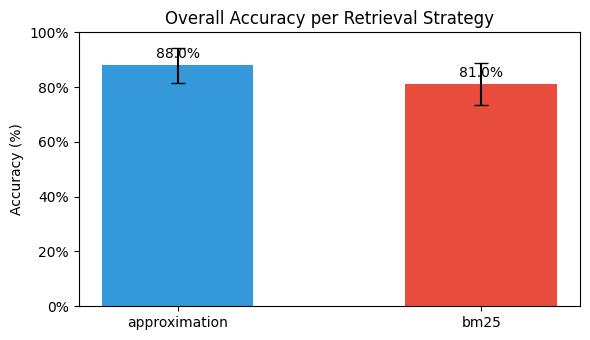

In [15]:
summary_rows = []
for s, df in raw.items():
    n       = len(df)
    n_true  = df["correct"].sum()
    acc     = n_true / n if n else float("nan")
    se      = np.sqrt(acc * (1 - acc) / n) if n else float("nan")
    summary_rows.append({
        "strategy":      s,
        "n":             n,
        "n_correct":     int(n_true),
        "accuracy":      acc,
        "ci95":          1.96 * se,
        "pct_correct":   f"{acc * 100:.1f}%",
    })

summary_df = pd.DataFrame(summary_rows).set_index("strategy")
display(summary_df[["n", "n_correct", "pct_correct", "accuracy", "ci95"]])

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#3498db" if s in ("approximation", "vector") else "#e74c3c" for s in summary_df.index]
bars = ax.bar(summary_df.index, summary_df["accuracy"] * 100, color=colors,
              yerr=summary_df["ci95"] * 100, capsize=5, width=0.5)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Overall Accuracy per Retrieval Strategy")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, row in zip(bars, summary_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{row.accuracy * 100:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_overall_accuracy.png", dpi=150)
plt.show()

## 3. Per-Decile Accuracy — Popularity Bias

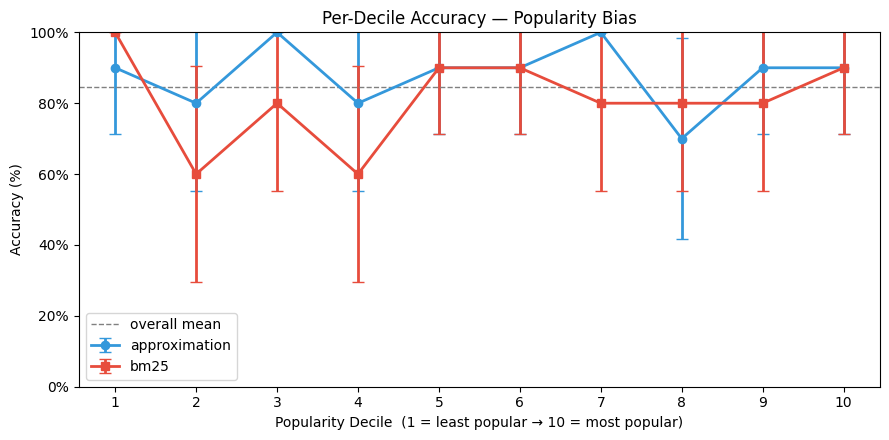


--- approximation ---


,accuracy,ci95,n
decile,,,
1,90.0%,±18.6%,10
2,80.0%,±24.8%,10
3,100.0%,±0.0%,10
4,80.0%,±24.8%,10
5,90.0%,±18.6%,10
6,90.0%,±18.6%,10
7,100.0%,±0.0%,10
8,70.0%,±28.4%,10
9,90.0%,±18.6%,10



--- bm25 ---


,accuracy,ci95,n
decile,,,
1,100.0%,±0.0%,10
2,60.0%,±30.4%,10
3,80.0%,±24.8%,10
4,60.0%,±30.4%,10
5,90.0%,±18.6%,10
6,90.0%,±18.6%,10
7,80.0%,±24.8%,10
8,80.0%,±24.8%,10
9,80.0%,±24.8%,10


In [16]:
strategy_colors = {
    "approximation": "#3498db",
    "vector":        "#3498db",
    "bm25":          "#e74c3c",
    "hybrid":        "#27ae60",
}
strategy_markers = {
    "approximation": "o",
    "vector":        "o",
    "bm25":          "s",
    "hybrid":        "D",
}

fig, ax = plt.subplots(figsize=(9, 4.5))

decile_tables: dict[str, pd.DataFrame] = {}

for s, df in raw.items():
    df_valid = df.dropna(subset=["decile"]).copy()
    df_valid["decile"] = df_valid["decile"].astype(int)

    rows = []
    for d in range(NUM_DECILES):
        sub  = df_valid[df_valid["decile"] == d]
        n    = len(sub)
        if n == 0:
            rows.append({"decile": d + 1, "accuracy": np.nan, "ci95": np.nan, "n": 0})
            continue
        acc  = sub["correct"].mean()
        se   = np.sqrt(acc * (1 - acc) / n) if n > 1 else 0.0
        rows.append({"decile": d + 1, "accuracy": acc, "ci95": 1.96 * se, "n": n})

    dt = pd.DataFrame(rows)
    decile_tables[s] = dt

    color  = strategy_colors.get(s, "#888")
    marker = strategy_markers.get(s, "o")
    ax.errorbar(
        dt["decile"], dt["accuracy"] * 100,
        yerr=dt["ci95"] * 100,
        label=s, color=color, marker=marker,
        linewidth=2, markersize=6, capsize=4,
    )

ax.set_xlabel("Popularity Decile  (1 = least popular → 10 = most popular)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Decile Accuracy — Popularity Bias")
ax.set_xticks(range(1, NUM_DECILES + 1))
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(combined["correct"].mean() * 100, color="grey", linestyle="--",
           linewidth=1, label="overall mean")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_decile_accuracy.png", dpi=150)
plt.show()

# Print table
for s, dt in decile_tables.items():
    print(f"\n--- {s} ---")
    display(dt.set_index("decile").style.format({"accuracy": "{:.1%}", "ci95": "±{:.1%}", "n": "{:,.0f}"}))

## 4. Retrieval Quality — Recall@K

Uses `retrieved_doc_ids` from the result metadata to check whether the target
document (`wikipedia_id`) appeared in the retrieved set — independently of
whether the LLM answer was judged correct.

* **Hit@K** — 1 if the target doc is among the top-K retrieved IDs, else 0.  
  Because the pipeline writes all retrieved IDs into `retrieved_doc_ids`, hit
  is computed directly from that list (no re-truncation at K needed unless you
  want to simulate lower K values).  
* **Per-decile Recall** — shows whether the retriever surfaces documents from
  less-popular deciles as reliably as popular ones.

,n,hits,pct_hit,recall,ci95
strategy,,,,,
approximation,100,30,30.0%,0.30,0.089818
bm25,100,21,21.0%,0.21,0.079832


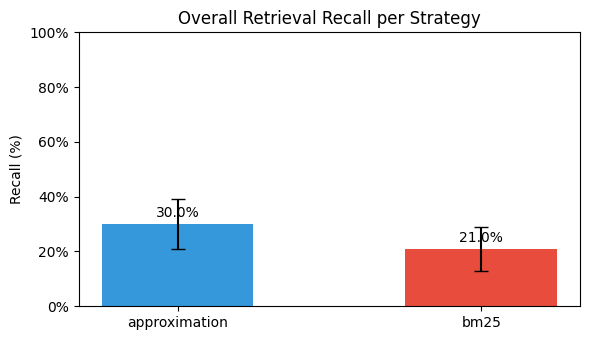

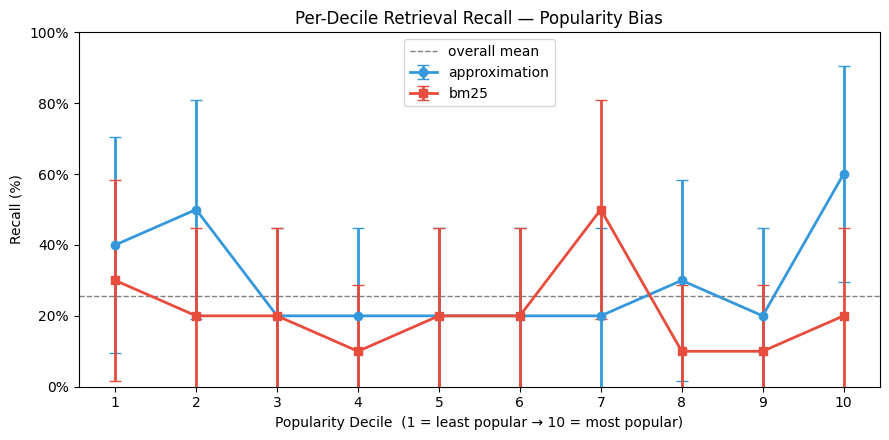

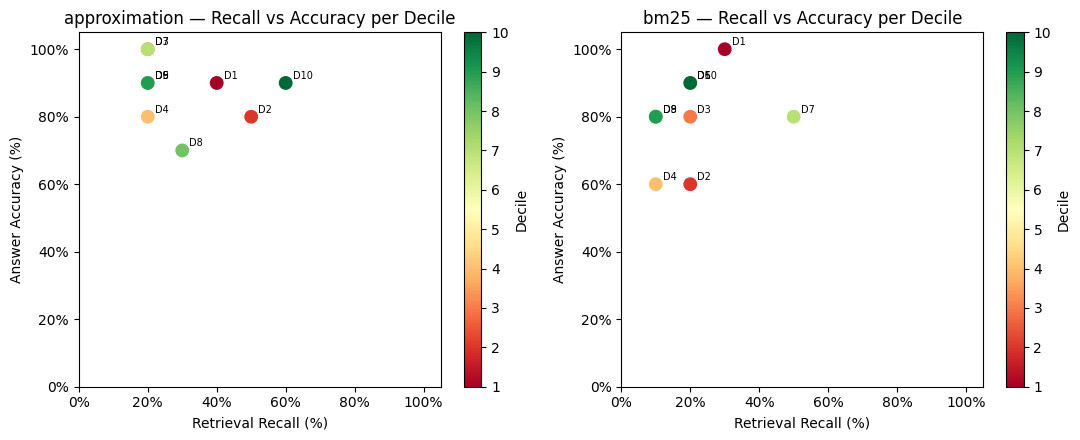


--- approximation ---


,recall,ci95,n
decile,,,
1,40.0%,±30.4%,10
2,50.0%,±31.0%,10
3,20.0%,±24.8%,10
4,20.0%,±24.8%,10
5,20.0%,±24.8%,10
6,20.0%,±24.8%,10
7,20.0%,±24.8%,10
8,30.0%,±28.4%,10
9,20.0%,±24.8%,10



--- bm25 ---


,recall,ci95,n
decile,,,
1,30.0%,±28.4%,10
2,20.0%,±24.8%,10
3,20.0%,±24.8%,10
4,10.0%,±18.6%,10
5,20.0%,±24.8%,10
6,20.0%,±24.8%,10
7,50.0%,±31.0%,10
8,10.0%,±18.6%,10
9,10.0%,±18.6%,10


In [17]:
# ── Retrieval hit rate ────────────────────────────────────────────────────────

# Overall hit rate per strategy
retrieval_summary_rows = []
for s, df in raw.items():
    has_ids = df["retrieved_doc_ids"].apply(bool).sum()
    if has_ids == 0:
        print(f"[{s}] No retrieved_doc_ids found in metadata — skipping retrieval analysis.")
        print("      Make sure the pipeline writes 'retrieved_doc_ids' into the metadata dict.")
        continue
    n    = len(df)
    hits = df["hit"].sum()
    rate = hits / n if n else float("nan")
    se   = np.sqrt(rate * (1 - rate) / n) if n else float("nan")
    retrieval_summary_rows.append({
        "strategy":  s,
        "n":         n,
        "hits":      int(hits),
        "recall": rate,
        "ci95":      1.96 * se,
        "pct_hit":   f"{rate * 100:.1f}%",
    })

if not retrieval_summary_rows:
    print("No retrieval data available — section skipped.")
else:
    ret_summary_df = pd.DataFrame(retrieval_summary_rows).set_index("strategy")
    display(ret_summary_df[["n", "hits", "pct_hit", "recall", "ci95"]])

    # ── Bar chart: overall retrieval recall ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 3.5))
    colors = [strategy_colors.get(s, "#888") for s in ret_summary_df.index]
    bars = ax.bar(
        ret_summary_df.index, ret_summary_df["recall"] * 100,
        color=colors, yerr=ret_summary_df["ci95"] * 100,
        capsize=5, width=0.5,
    )
    ax.set_ylabel("Recall (%)")
    ax.set_title("Overall Retrieval Recall per Strategy")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    for bar, row in zip(bars, ret_summary_df.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{row.recall * 100:.1f}%",
            ha="center", va="bottom", fontsize=10,
        )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_retrieval_recall.png", dpi=150)
    plt.show()

    # ── Per-decile retrieval recall ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4.5))
    decile_recall_tables: dict[str, pd.DataFrame] = {}

    for s, df in raw.items():
        if not df["retrieved_doc_ids"].apply(bool).sum():
            continue
        df_valid = df.dropna(subset=["decile"]).copy()
        df_valid["decile"] = df_valid["decile"].astype(int)

        rows = []
        for d in range(NUM_DECILES):
            sub = df_valid[df_valid["decile"] == d]
            n   = len(sub)
            if n == 0:
                rows.append({"decile": d + 1, "recall": np.nan, "ci95": np.nan, "n": 0})
                continue
            rate = sub["hit"].mean()
            se   = np.sqrt(rate * (1 - rate) / n) if n > 1 else 0.0
            rows.append({"decile": d + 1, "recall": rate, "ci95": 1.96 * se, "n": n})

        drt = pd.DataFrame(rows)
        decile_recall_tables[s] = drt

        color  = strategy_colors.get(s, "#888")
        marker = strategy_markers.get(s, "o")
        ax.errorbar(
            drt["decile"], drt["recall"] * 100,
            yerr=drt["ci95"] * 100,
            label=s, color=color, marker=marker,
            linewidth=2, markersize=6, capsize=4,
        )

    ax.set_xlabel("Popularity Decile  (1 = least popular \u2192 10 = most popular)")
    ax.set_ylabel("Recall (%)")
    ax.set_title("Per-Decile Retrieval Recall — Popularity Bias")
    ax.set_xticks(range(1, NUM_DECILES + 1))
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    if decile_recall_tables:
        overall_hit = combined[combined["retrieved_doc_ids"].apply(bool)]["hit"].mean()
        ax.axhline(overall_hit * 100, color="grey", linestyle="--",
                   linewidth=1, label="overall mean")
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_decile_recall.png", dpi=150)
    plt.show()

    # ── Accuracy vs retrieval recall scatter ──────────────────────────────────
    # Shows whether correct answers require a retrieval hit, or the LLM can
    # recover even when the wrong document is retrieved.
    fig, axes = plt.subplots(1, len(decile_recall_tables), figsize=(5.5 * len(decile_recall_tables), 4.5))
    if len(decile_recall_tables) == 1:
        axes = [axes]

    for ax, (s, drt) in zip(axes, decile_recall_tables.items()):
        dt = decile_tables.get(s)
        if dt is None:
            continue
        merged_d = drt.merge(dt, on="decile", suffixes=("_recall", "_acc"))
        sc = ax.scatter(
            merged_d["recall"] * 100,
            merged_d["accuracy"] * 100,
            c=merged_d["decile"],
            cmap="RdYlGn", s=80, zorder=3,
        )
        for _, row in merged_d.iterrows():
            ax.annotate(
                f"D{int(row['decile'])}",
                (row["recall"] * 100, row["accuracy"] * 100),
                textcoords="offset points", xytext=(5, 3), fontsize=7,
            )
        ax.set_xlabel("Retrieval Recall (%)")
        ax.set_ylabel("Answer Accuracy (%)")
        ax.set_title(f"{s} — Recall vs Accuracy per Decile")
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 105)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.colorbar(sc, ax=ax, label="Decile")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_recall_vs_accuracy.png", dpi=150)
    plt.show()

    # ── Per-decile recall tables ──────────────────────────────────────────────
    for s, drt in decile_recall_tables.items():
        print(f"\n--- {s} ---")
        display(
            drt.set_index("decile").style.format(
                {"recall": "{:.1%}", "ci95": "\u00b1{:.1%}", "n": "{:,.0f}"}
            )
        )

## 5. Per-Dataset Breakdown

In [18]:
dataset_rows = []
for s, df in raw.items():
    for ds, sub in df.groupby("dataset"):
        n   = len(sub)
        acc = sub["correct"].mean()
        se  = np.sqrt(acc * (1 - acc) / n) if n > 1 else 0.0
        dataset_rows.append({
            "strategy": s,
            "dataset":  ds,
            "n":        n,
            "accuracy": acc,
            "ci95":     1.96 * se,
        })

ds_df = pd.DataFrame(dataset_rows)
datasets = ds_df["dataset"].unique()

if len(datasets) > 1:
    fig, axes = plt.subplots(1, len(LOADED), figsize=(5 * len(LOADED), 4), sharey=True)
    if len(LOADED) == 1:
        axes = [axes]
    for ax, s in zip(axes, LOADED):
        sub = ds_df[ds_df["strategy"] == s].sort_values("accuracy", ascending=False)
        bars = ax.barh(sub["dataset"], sub["accuracy"] * 100,
                       xerr=sub["ci95"] * 100, capsize=4,
                       color=strategy_colors.get(s, "#888"))
        ax.set_title(s)
        ax.set_xlabel("Accuracy (%)")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xlim(0, 100)
        for bar, row in zip(bars, sub.itertuples()):
            ax.text(row.accuracy * 100 + 1, bar.get_y() + bar.get_height() / 2,
                    f"{row.accuracy * 100:.1f}%  (n={row.n:,})",
                    va="center", fontsize=8)
    fig.suptitle("Accuracy by Dataset and Strategy", fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_dataset_accuracy.png", dpi=150)
    plt.show()
else:
    print(f"Only one dataset ({datasets[0]}) — skipping grouped chart.")

display(
    ds_df.pivot_table(index="dataset", columns="strategy", values="accuracy")
    .style.format("{:.1%}")
    .set_caption("Accuracy by Dataset × Strategy")
)

Only one dataset (natural_questions) — skipping grouped chart.


strategy,approximation,bm25
dataset,,
natural_questions,88.0%,81.0%


## 6. Score Distribution & Failure Mode Inspection

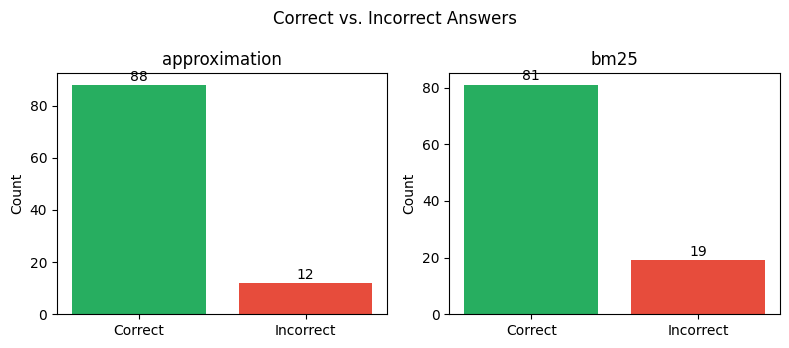

In [19]:
# --- 5a. Correct vs incorrect counts per strategy ---
fig, axes = plt.subplots(1, len(LOADED), figsize=(4 * len(LOADED), 3.5))
if len(LOADED) == 1:
    axes = [axes]

for ax, s in zip(axes, LOADED):
    vc = raw[s]["correct"].value_counts().reindex([True, False], fill_value=0)
    ax.bar(["Correct", "Incorrect"], vc.values,
           color=["#27ae60", "#e74c3c"])
    ax.set_title(s)
    ax.set_ylabel("Count")
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=10)

fig.suptitle("Correct vs. Incorrect Answers", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_score_distribution.png", dpi=150)
plt.show()

In [20]:
# --- 5b. Sample of failures (incorrect answers + judge reasoning) ---
N_SAMPLES = 5

for s, df in raw.items():
    failures = df[~df["correct"]].head(N_SAMPLES)
    if failures.empty:
        print(f"[{s}] No failures found.")
        continue
    print(f"\n{'='*70}")
    print(f" Strategy: {s}  ({len(df[~df['correct']]):,} failures total)")
    print(f"{'='*70}")
    for _, row in failures.iterrows():
        print(f"\n  Question  : {row['question'][:120]}")
        print(f"  Answer    : {str(row['proposed_answer'])[:120]}")
        print(f"  Reasoning : {str(row['reasoning'])[:200]}")
        print(f"  Decile    : {row.get('decile', '?')}  |  Dataset: {row.get('dataset', '?')}")


 Strategy: approximation  (12 failures total)

  Question  : which episode does gideon die in criminal minds
  Answer    : In Season 2 of Criminal Minds, Dr. Abel Gideon dies in the episode "Reckoner".
  Reasoning : The proposed answer incorrectly states that Dr. Abel Gideon dies in Season 2, while he actually dies in Season 3. Additionally, the question specifically asks about Gideon, not Abel Gideon.
  Decile    : 0  |  Dataset: natural_questions

  Question  : who is playing in the peach bowl this year
  Answer    : The teams playing in the 2018 Peach Bowl are the Michigan Wolverines and the Florida Gators.
  Reasoning : The proposed answer refers to the 2018 Peach Bowl instead of the current year's game, making it irrelevant to the question asked.
  Decile    : 1  |  Dataset: natural_questions

  Question  : who won the game between auburn and ufc
  Answer    : The document does not provide information on the winner of the game between Auburn and UFC.
  Reasoning : The proposed an

## 7. Cross-Strategy Comparison

For questions that appear in both strategy results, compare agreement.

Matched questions: 100
  Both correct  : 75  (75.0%)
  Only approximation  : 13  (13.0%)
  Only bm25           : 6  (6.0%)
  Neither       : 6  (6.0%)


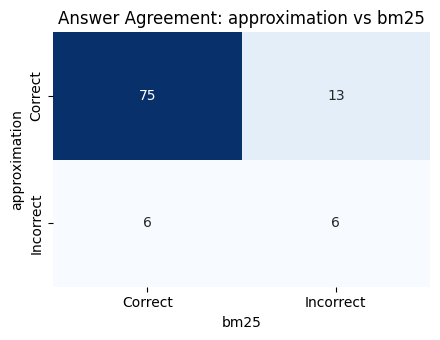

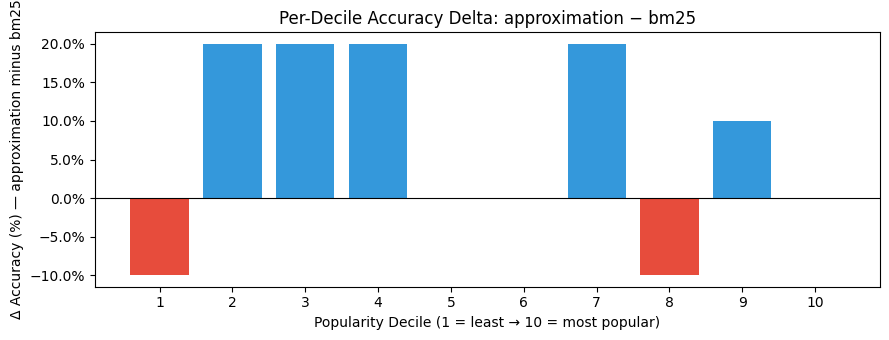

In [21]:
if len(LOADED) >= 2:
    s1, s2 = LOADED[0], LOADED[1]
    df1 = raw[s1][["question", "correct", "decile"]].rename(columns={"correct": f"correct_{s1}"})
    df2 = raw[s2][["question", "correct"]].rename(columns={"correct": f"correct_{s2}"})

    merged = df1.merge(df2, on="question", how="inner")
    total  = len(merged)

    both_correct   = ((merged[f"correct_{s1}"])  & (merged[f"correct_{s2}"])).sum()
    only_s1        = ((merged[f"correct_{s1}"])  & ~(merged[f"correct_{s2}"])).sum()
    only_s2        = (~(merged[f"correct_{s1}"]) & (merged[f"correct_{s2}"])).sum()
    neither        = (~(merged[f"correct_{s1}"]) & ~(merged[f"correct_{s2}"])).sum()

    print(f"Matched questions: {total:,}")
    print(f"  Both correct  : {both_correct:,}  ({both_correct/total:.1%})")
    print(f"  Only {s1:15s}: {only_s1:,}  ({only_s1/total:.1%})")
    print(f"  Only {s2:15s}: {only_s2:,}  ({only_s2/total:.1%})")
    print(f"  Neither       : {neither:,}  ({neither/total:.1%})")

    # Agreement heatmap
    ct = pd.crosstab(
        merged[f"correct_{s1}"].map({True: "Correct", False: "Incorrect"}),
        merged[f"correct_{s2}"].map({True: "Correct", False: "Incorrect"}),
        rownames=[s1], colnames=[s2],
    )
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Answer Agreement: {s1} vs {s2}")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_strategy_agreement.png", dpi=150)
    plt.show()

    # Per-decile delta (s1 accuracy minus s2 accuracy)
    delta_rows = []
    merged["decile"] = merged["decile"].dropna()
    for d in range(NUM_DECILES):
        sub = merged[merged["decile"] == d]
        if len(sub) == 0:
            continue
        delta = sub[f"correct_{s1}"].mean() - sub[f"correct_{s2}"].mean()
        delta_rows.append({"decile": d + 1, "delta": delta, "n": len(sub)})

    if delta_rows:
        delta_df = pd.DataFrame(delta_rows)
        fig, ax = plt.subplots(figsize=(9, 3.5))
        bar_colors = ["#3498db" if v >= 0 else "#e74c3c" for v in delta_df["delta"]]
        ax.bar(delta_df["decile"], delta_df["delta"] * 100, color=bar_colors)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Popularity Decile (1 = least → 10 = most popular)")
        ax.set_ylabel(f"Δ Accuracy (%) — {s1} minus {s2}")
        ax.set_title(f"Per-Decile Accuracy Delta: {s1} − {s2}")
        ax.set_xticks(range(1, NUM_DECILES + 1))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "fig_decile_delta.png", dpi=150)
        plt.show()
else:
    print("Only one strategy loaded — cross-strategy comparison skipped.")

## 8. Export Summary

In [22]:
# --- 8a. Overall accuracy summary CSV ---
summary_df.to_csv(RESULTS_DIR / "summary_overall.csv")
print(f"Saved: {RESULTS_DIR / 'summary_overall.csv'}")

# --- 8b. Per-decile accuracy CSVs ---
for s, dt in decile_tables.items():
    out = RESULTS_DIR / f"summary_decile_{s}.csv"
    dt.to_csv(out, index=False)
    print(f"Saved: {out}")

# --- 8c. Dataset breakdown CSV ---
ds_df.to_csv(RESULTS_DIR / "summary_datasets.csv", index=False)
print(f"Saved: {RESULTS_DIR / 'summary_datasets.csv'}")

# --- 8d. Retrieval recall summaries ---
if 'ret_summary_df' in dir():
    ret_summary_df.to_csv(RESULTS_DIR / "summary_retrieval_overall.csv")
    print(f"Saved: {RESULTS_DIR / 'summary_retrieval_overall.csv'}")

if 'decile_recall_tables' in dir():
    for s, drt in decile_recall_tables.items():
        out = RESULTS_DIR / f"summary_decile_recall_{s}.csv"
        drt.to_csv(out, index=False)
        print(f"Saved: {out}")

print("\nAll figures and summaries saved to:", RESULTS_DIR)

Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_overall.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_approximation.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_bm25.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_datasets.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_retrieval_overall.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_recall_approximation.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo/summary_decile_recall_bm25.csv

All figures and summaries saved to: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_nq_turbo
